Deep Generative Replays

In [1]:
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

Setting up Hyperparameters

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 1e-3
batch_size = 64
epochs_per_task = 5
tasks = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]

In [3]:
print(f"Using device: {device}")

Using device: cpu


Dataset Loading and splitting

In [4]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [5]:
train_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=False, download=True, transform=mnist_transform)

In [6]:
# Filter by Digits

def filter_by_digits(dataset, digits):
    indices = [i for i, (_, label) in enumerate(dataset) if label in digits]
    return Subset(dataset, indices)

In [7]:
# Get split MNIST datasets for each task
def get_split_mnist_datasets(tasks_digits):
    train_subset = filter_by_digits(train_dataset, tasks_digits)
    test_subset = filter_by_digits(test_dataset, tasks_digits)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

Defining the MNIST MLP

In [8]:
class MNISTMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=400, output_size=10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.fc(x)

Instantiate Model, optimizer, criterion and task loaders

In [9]:
model = MNISTMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [10]:
task_loaders = [get_split_mnist_datasets(task) for task in tasks]

Training Init

In [11]:
accuracy_history = np.zeros((len(tasks), len(tasks)))

In [12]:
# Evaluation Function
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100 if total > 0 else 0.0

In [13]:
# Training Loop
for train_task_idx, (train_loader, test_loader) in enumerate(task_loaders):
    print(f"\n--- Training on Task {train_task_idx + 1} -- (Digits: {tasks[train_task_idx]})")
    for epoch in range(epochs_per_task):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs_per_task} ----- Loss: {running_loss / len(train_loader):.4f}")
    print(f"--- Evaluating after Task {train_task_idx + 1} ---")
    for eval_task_idx, (_, test_loader) in enumerate(task_loaders):
        acc = evaluate(model, test_loader)
        accuracy_history[eval_task_idx, train_task_idx] = acc
        print(f"  Accuracy on Task {eval_task_idx + 1} (Digits {tasks[eval_task_idx]}): {acc:.2f}%")


--- Training on Task 1 -- (Digits: (0, 1))
Epoch 1/5 ----- Loss: 0.0403
Epoch 2/5 ----- Loss: 0.0042
Epoch 3/5 ----- Loss: 0.0020
Epoch 4/5 ----- Loss: 0.0011
Epoch 5/5 ----- Loss: 0.0010
--- Evaluating after Task 1 ---
  Accuracy on Task 1 (Digits (0, 1)): 99.91%
  Accuracy on Task 2 (Digits (2, 3)): 0.00%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 2 -- (Digits: (2, 3))
Epoch 1/5 ----- Loss: 0.2642
Epoch 2/5 ----- Loss: 0.0407
Epoch 3/5 ----- Loss: 0.0247
Epoch 4/5 ----- Loss: 0.0183
Epoch 5/5 ----- Loss: 0.0113
--- Evaluating after Task 2 ---
  Accuracy on Task 1 (Digits (0, 1)): 0.00%
  Accuracy on Task 2 (Digits (2, 3)): 99.27%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 3 -- (Digits: (4, 5))
Epoch 1/5 ----- Loss: 0.4095
Epoch 2/5 ----- Loss: 0.0184
Epoch 3/5 ----

The model is forgetting all previous knowledge.

Plotting the forgetting curve

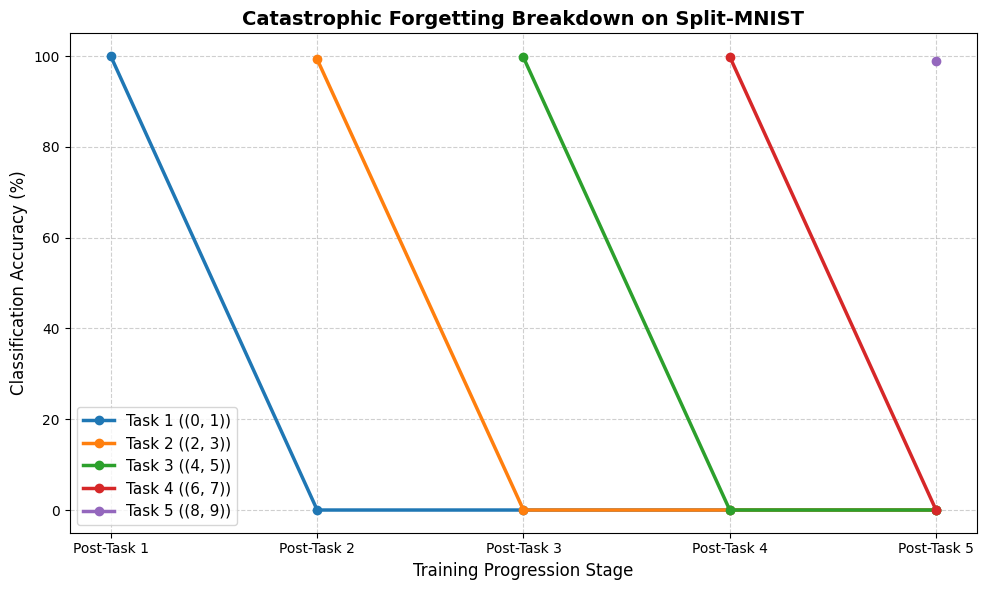

In [14]:
plt.figure(figsize=(10, 6))
x_ticks = [f"Post-Task {i+1}" for i in range(len(tasks))]

for task_idx in range(len(tasks)):
    y_values = accuracy_history[task_idx]
    plt.plot(x_ticks[task_idx:], y_values[task_idx:], marker='o', linewidth=2.5, label=f"Task {task_idx+1} ({tasks[task_idx]})")

plt.title("Catastrophic Forgetting Breakdown on Split-MNIST", fontsize=14, fontweight='bold')
plt.xlabel("Training Progression Stage", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)
plt.ylim(-5, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

Define Scholar Models - Generator - Solver

In [15]:
# Scholar using linear layers

# Solver
class Solver(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=400, output_size=10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.fc(x)

# Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_shape=(1, 28, 28), hidden_sizes=[256, 512, 1024]):
        super().__init__()
        self.img_shape = img_shape
        self.total_pixels = int(torch.prod(torch.tensor(img_shape)).item())
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[2], self.total_pixels),
            nn.Tanh(),
        )
    
    def forward(self, x):
        img = self.fc(x)
        return img.view(img.size(0), *self.img_shape)

# Critic
class Critic(nn.Module):
    def __init__(self, img_shape=(1, 28, 28), hidden_sizes=[512, 256, 1]):
        super().__init__()
        self.img_shape = img_shape
        self.total_pixels = int(torch.prod(torch.tensor(img_shape)).item())
        self.fc = nn.Sequential(
            nn.Linear(self.total_pixels, hidden_sizes[0]),
            nn.LayerNorm(hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.LayerNorm(hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], hidden_sizes[2]),
        )
    
    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        return self.fc(x_flat)

WGAN Criterion

In [16]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    alpha = torch.rand((batch_size, 1, 1, 1), device=device) if real_samples.dim() == 4 else torch.rand((batch_size, 1), device=device)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    critic_interpolates = critic(interpolates)
    grad_outputs = torch.ones(critic_interpolates.size(), device=device)

    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Training Task with Generative Replay

In [17]:
def train_task_with_replay(task_id, train_loader, prev_generator, prev_solver, generator, solver, critic, latent_dim=100, img_shape=(1, 28, 28), epochs=5, mix_ratio=0.5, n_critic=5, lambda_gp=10):
    g_optimizer = optim.Adam(generator.parameters(), lr=2e-4)
    c_optimizer = optim.Adam(critic.parameters(), lr=2e-4)
    s_optimizer = optim.Adam(solver.parameters(), lr=1e-3)

    criterion_cls = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)

            if task_id > 0 and prev_generator is not None and prev_solver is not None:
                with torch.no_grad():
                    z = torch.randn(batch_size, latent_dim, device=device)
                    fake_images = prev_generator(z)
                    fake_logits = prev_solver(fake_images)
                    fake_labels = torch.argmax(fake_logits, dim=1)
                real_size = int(batch_size * mix_ratio)
                replay_size = batch_size - real_size
                comb_images = torch.cat((images[:real_size], fake_images[:replay_size]), dim=0)
                comb_labels = torch.cat((labels[:real_size], fake_labels[:replay_size]), dim=0)
            else:
                comb_images, comb_labels = images, labels
            
            # TRAIN SOLVER
            s_optimizer.zero_grad()
            outputs = solver(comb_images)
            s_loss = criterion_cls(outputs, comb_labels)
            s_loss.backward()
            s_optimizer.step()

            for _ in range(n_critic):
                c_optimizer.zero_grad()
                if task_id > 0 and prev_generator is not None:
                    critic_input = comb_images
                else:
                    critic_input = images
                
                critic_batch_size = critic_input.size(0)
                z = torch.randn(critic_batch_size, latent_dim, device=device)
                fake_images = generator(z).detach()

                real_validity = critic(critic_input)
                fake_validity = critic(fake_images)
                gradient_penalty = compute_gradient_penalty(critic, critic_input, fake_images, device)
                c_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty
                c_loss.backward()
                c_optimizer.step()
            
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            gen_images = generator(z)
            g_loss = -torch.mean(critic(gen_images))
            g_loss.backward()
            g_optimizer.step()
        
        print(f"Epoch {epoch+1} Complete. Solver Loss: {s_loss.item():.4f} | Critic Loss: {c_loss.item():.4f} | Gen Loss: {g_loss.item():.4f}")

Defining Parameters

In [18]:
latent_dim = 100
img_shape = (1, 28, 28)
num_classes = 10

Instantiating Network

In [19]:
current_generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
current_solver = Solver().to(device)
critic = Critic().to(device)

prev_generator, prev_solver = None, None

In [20]:
# Training Loop
replay_accuracy_history = np.zeros((len(tasks), len(tasks)))

for train_task_idx, (train_loader, test_loader) in enumerate(task_loaders):
    print(f"\n--- Training on Task {train_task_idx + 1} -- (Digits: {tasks[train_task_idx]})")

    train_task_with_replay(
        task_id=train_task_idx,
        train_loader=train_loader,
        prev_generator=prev_generator,
        prev_solver=prev_solver,
        generator=current_generator,
        solver=current_solver,
        critic=critic,
        latent_dim=latent_dim,
        epochs=epochs_per_task
    )

    print(f"--- Evaluating after Replay Task {train_task_idx + 1} ---")
    for eval_task_idx, (_, eval_test_loader) in enumerate(task_loaders):
        acc = evaluate(current_solver, eval_test_loader)
        replay_accuracy_history[eval_task_idx, train_task_idx] = acc
        print(f"  Accuracy on Task {eval_task_idx + 1} (Digits {tasks[eval_task_idx]}): {acc:.2f}%")

    prev_generator = copy.deepcopy(current_generator)
    prev_solver = copy.deepcopy(current_solver)


--- Training on Task 1 -- (Digits: (0, 1))
Epoch 1 Complete. Solver Loss: 0.0017 | Critic Loss: -17.6144 | Gen Loss: 15.8341
Epoch 2 Complete. Solver Loss: 0.0002 | Critic Loss: -20.7745 | Gen Loss: 25.2327
Epoch 3 Complete. Solver Loss: 0.0006 | Critic Loss: -20.6565 | Gen Loss: 31.5859
Epoch 4 Complete. Solver Loss: 0.0000 | Critic Loss: -21.4782 | Gen Loss: 37.5982
Epoch 5 Complete. Solver Loss: 0.0000 | Critic Loss: -21.9716 | Gen Loss: 42.4739
--- Evaluating after Replay Task 1 ---
  Accuracy on Task 1 (Digits (0, 1)): 99.95%
  Accuracy on Task 2 (Digits (2, 3)): 0.00%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 2 -- (Digits: (2, 3))
Epoch 1 Complete. Solver Loss: 0.0170 | Critic Loss: -11.0887 | Gen Loss: 44.2315
Epoch 2 Complete. Solver Loss: 0.0506 | Critic Loss: -12.3283 | Gen Loss: 48.9753
Epoch 3 Complete. Solver Loss: 0.0074 | Critic Loss: -13.3076 | Gen Loss: 50.5